In [ ]:
# 1. 환경 설정 및 라이브러리 설치

In [4]:
!pip install stable-baselines3 gymnasium
!pip install swig
!pip install "gymnasium[box2d]"
import gymnasium as gym
from stable_baselines3 import PPO, SAC
from stable_baselines3.common.evaluation import evaluate_policy # Changed import path
import os

# 1. 환경 생성 (Continuous 버전)
env_name = "LunarLander-v3"
# continuous=True로 설정하여 연속적인 액션 공간 사용 (PPO/SAC 비교 용이)
env = gym.make(env_name, continuous=True, render_mode=None)

# 로그 저장 디렉토리
log_dir = "./logs/"
os.makedirs(log_dir, exist_ok=True)

# 2. 모델 정의 (PPO)
print("--- PPO 학습 시작 ---")
model_ppo = PPO("MlpPolicy", env, verbose=1, tensorboard_log=log_dir)
# 시간 관계상 100,000 step 정도면 착륙하는 꼴은 볼 수 있음 (제출용은 30~50만 권장)
model_ppo.learn(total_timesteps=100000, tb_log_name="PPO_LunarLander")
model_ppo.save("ppo_lunarlander_final")

# 3. 모델 정의 (SAC) - 비교군
print("--- SAC 학습 시작 ---")
model_sac = SAC("MlpPolicy", env, verbose=1, tensorboard_log=log_dir)
model_sac.learn(total_timesteps=100000, tb_log_name="SAC_LunarLander")
model_sac.save("sac_lunarlander_final")

# 4. 간단한 평가 및 출력
print("--- 평가 결과 ---")
mean_reward_ppo, std_reward_ppo = evaluate_policy(model_ppo, env, n_eval_episodes=10)
mean_reward_sac, std_reward_sac = evaluate_policy(model_sac, env, n_eval_episodes=10)

print(f"PPO Mean Reward: {mean_reward_ppo} +/- {std_reward_ppo}")
print(f"SAC Mean Reward: {mean_reward_sac} +/- {std_reward_sac}")

env.close()



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for box2d-py: filename=box2d_py-2.3.5-cp312-cp312-linux_x86_64.whl size=2399050 sha256=6933c64ed696c04c7a73da9b6735f1cc18e0c9fe028567bae6a04d884c4cb0b0
  Stored in directory: /root/.cache/pip/wheels/2a/e9/60/774da0bcd07f7dc7761a8590fa2d065e4069568e78dcdc3318
Successfully built box2d-py


/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

--- PPO 학습 시작 ---
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Logging to ./logs/PPO_LunarLander_1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 104      |
|    ep_rew_mean     | -218     |
| time/              |          |
|    fps             | 1155     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 109          |
|    ep_rew_mean          | -208         |
| time/                   |              |
|    fps                  | 786          |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0057943407 |
|    clip_fraction        | 0.0489       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.83        |
|    explained_variance   | -0.000255    |
|    learning_r

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


PPO Mean Reward: 159.16605969467474 +/- 70.22771342147404
SAC Mean Reward: 142.1417170726806 +/- 138.87534897784067


In [ ]:
# 2. 결과 영상 생성 및 저장

In [5]:
import gymnasium as gym
from stable_baselines3 import PPO, SAC
from gymnasium.wrappers import RecordVideo
import glob
import io
import base64
from IPython.display import HTML

def record_video(algo_name, model_path, video_folder='video'):
    # 비디오 저장을 위한 환경 래핑
    eval_env = gym.make("LunarLander-v3", continuous=True, render_mode="rgb_array")
    eval_env = RecordVideo(eval_env, video_folder=video_folder, name_prefix=algo_name,
                           episode_trigger=lambda x: x == 0) # 첫 에피소드만 녹화

    # 모델 불러오기
    if algo_name == "PPO":
        model = PPO.load(model_path)
    else:
        model = SAC.load(model_path)

    obs, _ = eval_env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs)
        obs, reward, terminated, truncated, info = eval_env.step(action)
        done = terminated or truncated

    eval_env.close()
    print(f"🎥 {algo_name} 영상 저장 완료! 왼쪽 폴더에서 video 폴더를 확인하세요.")

# PPO 영상 만들기 (파일이 있다면)
record_video("PPO", "ppo_lunarlander_final.zip")

# SAC 영상 만들기 (학습 끝나고 파일 생기면 실행)
# record_video("SAC", "sac_lunarlander_final.zip")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🎥 PPO 영상 저장 완료! 왼쪽 폴더에서 video 폴더를 확인하세요.


In [ ]:
# 3. 학습 결과 시각화 (Learning Curve)

📊 데이터 추출 중...
📂 로그 파일 발견: ./logs/SAC_LunarLander_1 (SAC)
📂 로그 파일 발견: ./logs/PPO_LunarLander_1 (PPO)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


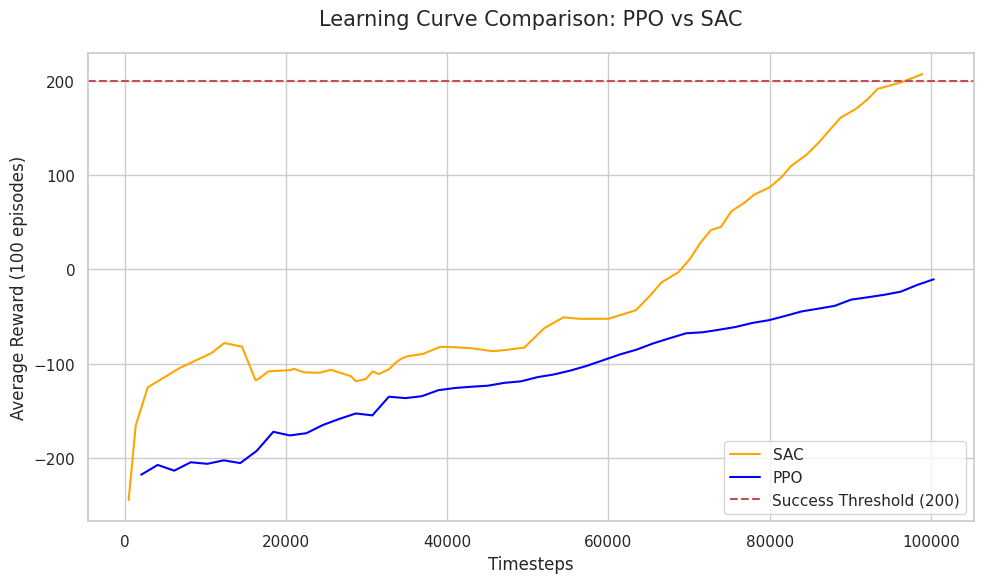

✅ 그래프 저장 완료! 왼쪽 파일 탭에서 'comparison_result.png'를 다운로드하세요.


In [6]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import seaborn as sns
import pandas as pd

# 그래프 스타일 설정 (논문 스타일)
sns.set(style="whitegrid")

def extract_tensorboard_data(log_dir):
    data = []
    # logs 폴더 내부를 탐색
    for root, dirs, files in os.walk(log_dir):
        for file in files:
            if "events.out.tfevents" in file:
                # 알고리즘 이름 파악 (폴더명에 PPO 또는 SAC가 포함되어 있다고 가정)
                algo = "Unknown"
                if "PPO" in root:
                    algo = "PPO"
                elif "SAC" in root:
                    algo = "SAC"

                print(f"📂 로그 파일 발견: {root} ({algo})")

                # 데이터 로드
                event_acc = EventAccumulator(os.path.join(root, file))
                event_acc.Reload()

                # 'rollout/ep_rew_mean' 태그가 있는지 확인 (SB3 기본 태그)
                tags = event_acc.Tags()['scalars']
                if 'rollout/ep_rew_mean' in tags:
                    events = event_acc.Scalars('rollout/ep_rew_mean')
                    for event in events:
                        data.append({
                            "Timesteps": event.step,
                            "Average Reward": event.value,
                            "Algorithm": algo
                        })
    return pd.DataFrame(data)

# 1. 데이터 추출
print("📊 데이터 추출 중...")
log_dir = "./logs/" # 아까 학습할 때 지정한 로그 폴더
df = extract_tensorboard_data(log_dir)

if not df.empty:
    # 2. 그래프 그리기
    plt.figure(figsize=(10, 6))

    # Seaborn으로 부드러운 선 그래프 그리기
    sns.lineplot(data=df, x="Timesteps", y="Average Reward", hue="Algorithm", palette={"PPO": "blue", "SAC": "orange"})

    # 목표 달성 기준선 (200점) - 착륙 성공 기준
    plt.axhline(y=200, color='r', linestyle='--', label='Success Threshold (200)')

    # 그래프 꾸미기
    plt.title("Learning Curve Comparison: PPO vs SAC", fontsize=15, pad=20)
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Average Reward (100 episodes)", fontsize=12)
    plt.legend(loc='lower right')

    # 저장
    plt.tight_layout()
    plt.savefig("comparison_result.png", dpi=300)
    plt.show()
    print("✅ 그래프 저장 완료! 왼쪽 파일 탭에서 'comparison_result.png'를 다운로드하세요.")
else:
    print("⚠️ 로그 데이터를 찾지 못했습니다. './logs/' 폴더 안에 파일이 있는지 확인해주세요.")